Walidowałyśmy projekt z danymi dotyczące 6 gatunków meduz.
Początkowo przedstawiono nam jedynie wyniki dla algorytmu Agglomerative Clustering, 
ale postanowiliśmy rozszerzyć analizę o KMeans i DBSCAN, aby sprawdzić, które podejście działa najlepiej.

W KMeans najlepsze wyniki uzyskaliśmy przy k=4:
* Silhouette Score: 0.0470
* Calinski-Harabasz Index: 188.18
* Davies-Bouldin Index: 3.9362
* Szum: 0 punktów
* Rozkład klastrów: 1841, 1336, 976, 741

Mimo niskiej wartość Silhouette, model lepiej separował dane niż inne algorytmy.

Testowaliśmy model DBSCAN z eps=16 i min_samples=6:
* Liczba klastrów: 8 (w tym jeden dominujący)
* Silhouette Score: 0.0438
* Davies-Bouldin Index: 1.8243
* Szum: 220 punktów
* Rozkład klastrów:
    * Klaster 0: 4598
    * Pozostałe klastry: bardzo małe (od 7 do 18 punktów)

DBSCAN przypisał większość danych do jednego klastra, co wskazuje na niedopasowanie parametrów lub zbyt dużą skalę skupienia danych.

Agglomerative Clustering
Model wykonaliśmy na podzbiorze trzech z sześciu klas, by przetestować jakość separacji przy mniejszej liczbie gatunków. Ustawiliśmy n_clusters=3.

* Rozkład klastrów:
  * Klaster 0: 1030
  * Klaster 1: 1289
  * Klaster 2: 137
* Klaster 0 zawierał w 93% jeden konkretny gatunek, co sugeruje dobrą zgodność dla tej klasy, 
ale ogólnie wystąpiła duża nierównowaga między klastrami.

Wnioski:
* KMeans z k=4 dawał najbardziej stabilne i równomierne klastry, mimo niskich metryk.
* DBSCAN nie sprawdził się dobrze — większość danych przypisana do jednego klastra.
* Agglomerative Clustering lepiej separował jeden z gatunków przy ograniczeniu do 3 klas, ale rozkład klastrów był bardzo niezrównoważony.

In [1]:
import matplotlib.pyplot as plt
import skimage
import os
from PIL import Image
import numpy as np
import random
from skimage.filters import threshold_otsu, threshold_local
from skimage.color import rgb2gray
import pandas as pd
import seaborn as sns

In [2]:
# Wczytanie embeddingow dotyczących obrazów meduz
df = pd.read_csv(r"new_data\features\all_features.csv")

In [3]:
df

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,label
0,-1.379052,-1.469439,0.038016,4.597365,6.131796,6.304124,1.818924,1.845292,-0.052930,0.802556,...,-1.488169,-0.251238,0.590376,1.331732,0.033397,-0.524358,0.535217,-1.029683,1.385180,mauve_stinger_jellyfish
1,12.056454,6.656796,2.793706,-1.482445,-0.054236,-0.252748,1.474137,-0.231155,0.799924,1.092141,...,0.845074,-0.454708,-0.245973,-0.471815,-0.536990,-0.537583,-0.030544,-0.570849,-0.173692,Moon_jellyfish
2,-3.169790,-6.364208,-3.107678,3.138218,2.680418,0.606145,1.301610,0.336014,2.344538,-2.000508,...,-0.666477,-0.015823,-0.973929,0.627987,0.827529,0.096399,-0.298162,0.114352,-0.378461,lions_mane_jellyfish
3,-7.538655,-0.860060,4.244933,1.166884,-1.024383,1.981291,3.354955,-2.936236,3.992783,-6.762512,...,-0.605043,-0.242136,-0.225781,-0.474932,0.102012,-0.294191,-0.415029,-0.317817,-0.090883,barrel_jellyfish
4,1.320162,-1.181104,1.382121,-2.701721,-6.510922,0.103525,-0.223845,3.693023,-4.778193,-0.473610,...,-0.041578,-0.053531,0.013013,0.462049,-0.774928,-0.400183,-0.177392,0.461236,0.073551,compass_jellyfish
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4889,-0.949504,-7.158218,-1.507189,-1.693069,-3.495238,-2.511450,5.074431,1.370732,6.902033,-1.503647,...,0.334268,-0.430193,0.656089,-0.627273,0.527458,-0.224733,-0.353620,0.002929,0.029773,lions_mane_jellyfish
4890,-2.441665,-1.903469,-0.496063,2.540545,3.435913,5.259140,-1.624611,1.415278,-3.909711,-1.879944,...,-0.502198,-0.058826,0.353578,-0.427912,-0.401634,0.220697,0.498131,-0.913368,-0.048718,compass_jellyfish
4891,2.970256,0.168088,3.205246,1.654348,3.369863,1.200398,-3.589286,-1.088812,-5.687056,-2.918817,...,1.649229,-0.504858,-0.017761,-0.278821,-0.353828,0.476544,0.966958,-0.279218,0.093379,blue_jellyfish
4892,8.168258,-2.942810,-0.115453,1.627771,-1.106622,-7.429671,-1.450931,0.698465,-2.531385,3.971310,...,-0.989936,0.284967,-0.449238,-0.708116,-0.439643,-0.387548,-0.502036,-0.348488,-0.465440,Moon_jellyfish


In [4]:
###Funkcja do tworzenia wykresu rozkładu gatunków w klastrach
def confusion_matrix(y_pred, algorythim_name,df=df):
    contingency_matrix = pd.crosstab(df['label'], y_pred)

    contingency_pct = contingency_matrix.div(contingency_matrix.sum(axis=1), axis=0) * 100

    annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        contingency_pct,
        annot=annot_pct,       
        fmt="",                
        cmap="Blues",
        cbar_kws={"label": "Percent (%)"}
    )
    plt.title(f"Rozkład gatunków w {len(np.unique(y_pred))} klastrach {algorythim_name} (row‐wise %)")
    plt.xlabel("Cluster")
    plt.ylabel("True Label (gatunek)")
    plt.tight_layout()
    plt.show()

In [5]:
from sklearn.metrics import adjusted_rand_score, v_measure_score, normalized_mutual_info_score, homogeneity_score, completeness_score, fowlkes_mallows_score
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

#Funkcja do obliczania metryk klastrowania
def metrics(true, pred, df_embeddings=df):
    print("Adjusted Rand Index (ARI):", adjusted_rand_score(true, pred))
    print("V-measure:", v_measure_score(true, pred))
    print("NMI:", normalized_mutual_info_score(true, pred))
    print("Homogeneity:", homogeneity_score(true, pred))
    print("Completeness:", completeness_score(true, pred))
    print("Fowlkes-Mallows Score:", fowlkes_mallows_score(true, pred))
    print("-------------------------------------------------")
    print("Silhouette Score:", silhouette_score(df_embeddings.drop(columns=['label']), pred))
    print("Davies-Bouldin Index:", davies_bouldin_score(df_embeddings.drop(columns=['label']), pred))
    print("Calinski-Harabasz Score:", calinski_harabasz_score(df_embeddings.drop(columns=['label']), pred))

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.manifold import TSNE
# Funkcja do generowania wykresu t-SNE dla klastrów
def plot_tsne_clusters(y_pred, algorythm_name, n_clusters=4,df_embeddings=df ,random_state=42, figsize=(8, 6), point_size=30):
    """
    Wygeneruj wykres t-SNE dla podanych embeddingów i etykiet klastrów.

    Parametry:
    ----------
    df_embeddings : pandas.DataFrame
        DataFrame zawierający kolumny embeddingów (np. wektory z ResNet). 
        Jeśli w DataFrame jest kolumna o nazwie 'label', zostanie ona automatycznie pominięta.
    y_pred : array-like (n_samples,)
        Tablica przewidzianych etykiet klastrów (wartości od 0 do n_clusters-1).
    n_clusters : int, opcjonalnie (domyślnie 4)
        Liczba klastrów (używana do wygenerowania odpowiedniej mapy kolorów).
    random_state : int, opcjonalnie (domyślnie 42)
        Ziarno losowości używane w TSNE, dla powtarzalności wyników.
    figsize : tuple, opcjonalnie (domyślnie (8, 6))
        Rozmiar figury w calach (szerokość, wysokość).
    point_size : int lub float, opcjonalnie (domyślnie 30)
        Rozmiar punktów na wykresie.

    Zwraca:
    -------
    None
        Funkcja jedynie wyświetla wykres; nie zwraca wartości.
    """

    if 'label' in df_embeddings.columns:
        X = df_embeddings.drop(columns=['label']).values
    else:
        X = df_embeddings

    tsne = TSNE(n_components=2, random_state=random_state)
    X_2d = tsne.fit_transform(X)

    base_cmap = plt.get_cmap('tab10')
    if n_clusters <= 10:
        colors = [base_cmap(i) for i in range(n_clusters)]
    else:
        colors = [base_cmap(i % 10) for i in range(n_clusters)]
    cmap = ListedColormap(colors)

    norm = BoundaryNorm(boundaries=np.arange(-0.5, n_clusters, 1), ncolors=cmap.N)

    plt.figure(figsize=figsize)
    sc = plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y_pred,
        cmap=cmap,
        norm=norm,
        s=point_size,
        edgecolor='k',
        linewidth=0.2
    )

    plt.title(f"t-SNE {algorythm_name} n_clusters={n_clusters})")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")

    cbar = plt.colorbar(sc, boundaries=np.arange(-0.5, n_clusters, 1), ticks=np.arange(0, n_clusters))
    cbar.set_label('Cluster')

    plt.tight_layout()
    plt.show()

In [7]:
#Ttrenowanie modelu Gaussian Mixture Model (GMM)
from sklearn.cluster import AgglomerativeClustering

X_df = df.drop(columns=['label'])

agg = AgglomerativeClustering(n_clusters=6, linkage='ward')

Adjusted Rand Index (ARI): 0.2842124678294592
V-measure: 0.3838532518441376
NMI: 0.38385325184413766
Homogeneity: 0.3710549043321483
Completeness: 0.3975660149944141
Fowlkes-Mallows Score: 0.4191363392056051
-------------------------------------------------
Silhouette Score: 0.029708580214102137
Davies-Bouldin Index: 4.165023900166524
Calinski-Harabasz Score: 121.35753959154343


C:\Temp\ipykernel_168\1839847248.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


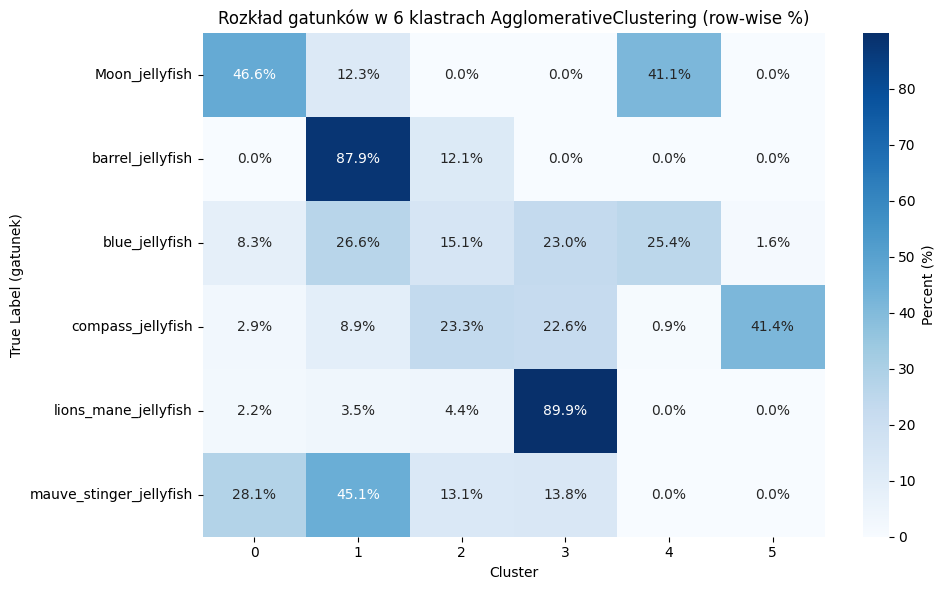

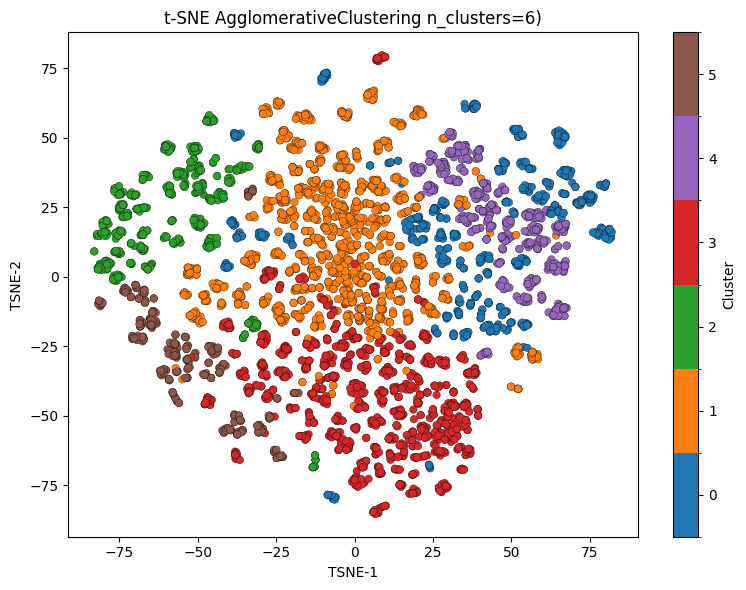

In [8]:
#Fittowanie modelu, metryki i wykresy, heatmapa przedstawia ile procent zdjęć danego gatunku znajduje się w danym klastrze
y_pred=agg.fit_predict(X_df)

metrics(df["label"],y_pred)
confusion_matrix(y_pred,"AgglomerativeClustering",df)
plot_tsne_clusters(y_pred, "AgglomerativeClustering", 6)

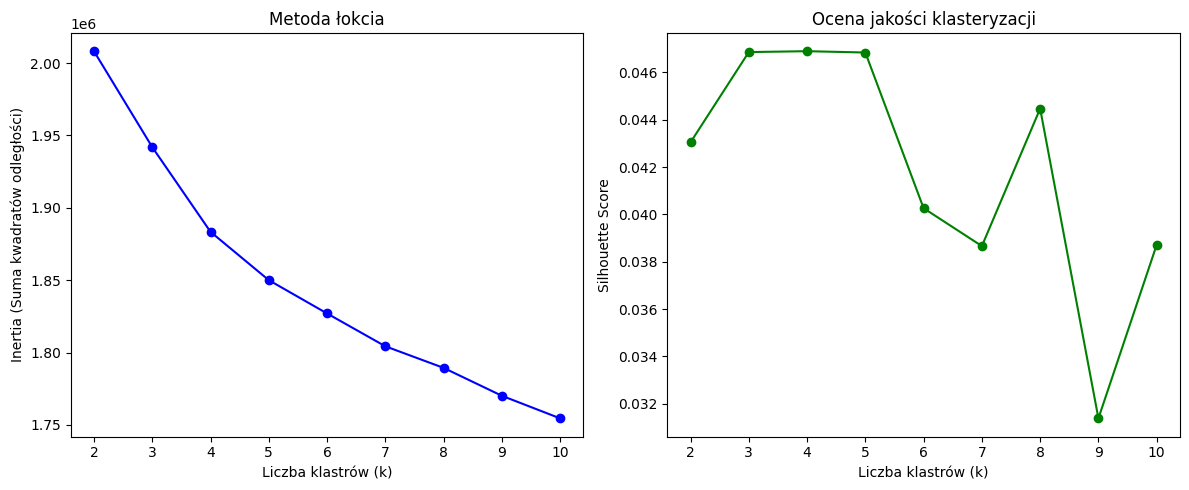

In [9]:
# proba na k-means

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


X=df.drop(columns=['label'])

#X = StandardScaler().fit_transform(df)

# Metoda łokcia
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Wykresy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inertia (Suma kwadratów odległości)')
plt.title('Metoda łokcia')

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'go-')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Silhouette Score')
plt.title('Ocena jakości klasteryzacji')

plt.tight_layout()
plt.show()

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_model = None

for k in range(2, 8):
    model = KMeans(n_clusters=k, init='k-means++', n_init=30, max_iter=500, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    
    print(f'k={k}, silhouette={score:.4f}')
    
    if score > best_score:
        best_score = score
        best_model = model

k=2, silhouette=0.0430
k=3, silhouette=0.0424
k=4, silhouette=0.0470
k=5, silhouette=0.0468
k=6, silhouette=0.0446
k=7, silhouette=0.0394


In [11]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from collections import Counter
import numpy as np

labels = best_model.predict(X)

sil_score = silhouette_score(X[labels != -1], labels[labels != -1])
ch_score = calinski_harabasz_score(X[labels != -1], labels[labels != -1])
db_score = davies_bouldin_score(X[labels != -1], labels[labels != -1])

noise_points = np.sum(labels == -1)
cluster_sizes = Counter(labels[labels != -1])

print(f"\nMetryki dla najlepszego modelu (k={len(set(labels)) - (1 if -1 in labels else 0)}):")
print(f"Silhouette Score:        {sil_score:.4f}")
print(f"Calinski-Harabasz Index: {ch_score:.4f}")
print(f"Davies-Bouldin Index:    {db_score:.4f}")
print(f"Noise points:            {noise_points}")
print(f"Cluster sizes:           {cluster_sizes}")


Metryki dla najlepszego modelu (k=4):
Silhouette Score:        0.0470
Calinski-Harabasz Index: 188.1762
Davies-Bouldin Index:    3.9362
Noise points:            0
Cluster sizes:           Counter({0: 1841, 3: 1336, 2: 976, 1: 741})


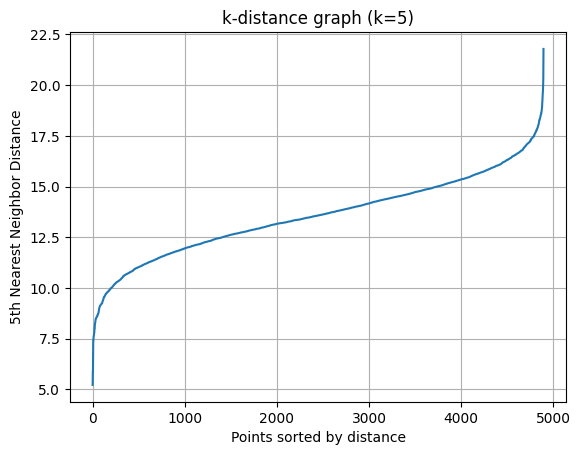

In [12]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
df=df.drop(columns=['label'])
X = StandardScaler().fit_transform(df)
#X = df.values
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, 4])  
plt.plot(distances)
plt.ylabel("5th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.title("k-distance graph (k=5)")
plt.grid()
plt.show()

In [13]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

best_result = None

for eps in np.arange(12.5, 17.5, 0.1):
    for min_samples in range(5, 6):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            sil = silhouette_score(X, labels)
            dbi = davies_bouldin_score(X, labels)
            print(f'eps={eps:.1f}, min_samples={min_samples} => Silhouette: {sil:.4f}, DBI: {dbi:.4f}')
            
            if best_result is None or sil > best_result['silhouette']:
                best_result = {
                    'eps': eps,
                    'min_samples': min_samples,
                    'silhouette': sil,
                    'davies_bouldin': dbi
                }

print("\nNajlepszy wynik:")
print(best_result)

eps=12.5, min_samples=5 => Silhouette: -0.0356, DBI: 2.2082
eps=12.6, min_samples=5 => Silhouette: -0.0323, DBI: 2.2118
eps=12.7, min_samples=5 => Silhouette: -0.0279, DBI: 2.2234
eps=12.8, min_samples=5 => Silhouette: -0.0245, DBI: 2.2383
eps=12.9, min_samples=5 => Silhouette: -0.0207, DBI: 2.2539
eps=13.0, min_samples=5 => Silhouette: -0.0193, DBI: 2.2563
eps=13.1, min_samples=5 => Silhouette: -0.0173, DBI: 2.2663
eps=13.2, min_samples=5 => Silhouette: -0.0200, DBI: 2.2596
eps=13.3, min_samples=5 => Silhouette: -0.0181, DBI: 2.2622
eps=13.4, min_samples=5 => Silhouette: -0.0176, DBI: 2.2718
eps=13.5, min_samples=5 => Silhouette: -0.0159, DBI: 2.2817
eps=13.6, min_samples=5 => Silhouette: -0.0155, DBI: 2.2834
eps=13.7, min_samples=5 => Silhouette: -0.0176, DBI: 2.2936
eps=13.8, min_samples=5 => Silhouette: -0.0162, DBI: 2.3025
eps=13.9, min_samples=5 => Silhouette: -0.0131, DBI: 2.3110
eps=14.0, min_samples=5 => Silhouette: -0.0153, DBI: 2.3114
eps=14.1, min_samples=5 => Silhouette: -

In [14]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np
from sklearn.decomposition import PCA

db = DBSCAN(eps=16, min_samples=6)
labels = db.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
silhouette = silhouette_score(X[labels != -1], labels[labels != -1])
davies_bouldin = davies_bouldin_score(X[labels != -1], labels[labels != -1])
    
noise_points = np.sum(labels == -1)
cluster_sizes = Counter(labels[labels != -1])
    
print(f'n_clusters: {n_clusters}')
print(f'Silhouette Score:        {silhouette:.4f}')
print(f'Davies-Bouldin Index:    {davies_bouldin:.4f}')
print(f'Noise points:            {noise_points}')
print(f'Cluster sizes:           {cluster_sizes}')

n_clusters: 8
Silhouette Score:        0.0438
Davies-Bouldin Index:    1.8243
Noise points:            220
Cluster sizes:           Counter({0: 4598, 4: 18, 1: 12, 2: 12, 3: 12, 7: 8, 5: 7, 6: 7})


In [15]:
from sklearn.cluster import AgglomerativeClustering

In [22]:
from sklearn.metrics import adjusted_rand_score, v_measure_score, normalized_mutual_info_score, homogeneity_score, completeness_score, fowlkes_mallows_score
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

#Funkcja do obliczania metryk klastrowania
def metrics(true, pred, df_embeddings=filtered_df):
    print("Adjusted Rand Index (ARI):", adjusted_rand_score(true, pred))
    print("V-measure:", v_measure_score(true, pred))
    print("NMI:", normalized_mutual_info_score(true, pred))
    print("Homogeneity:", homogeneity_score(true, pred))
    print("Completeness:", completeness_score(true, pred))
    print("Fowlkes-Mallows Score:", fowlkes_mallows_score(true, pred))
    print("-------------------------------------------------")
    print("Silhouette Score:", silhouette_score(df_embeddings.drop(columns=['label']), pred))
    print("Davies-Bouldin Index:", davies_bouldin_score(df_embeddings.drop(columns=['label']), pred))
    print("Calinski-Harabasz Score:", calinski_harabasz_score(df_embeddings.drop(columns=['label']), pred))

In [23]:
###Funkcja do tworzenia wykresu rozkładu gatunków w klastrach
def confusion_matrix(y_pred, algorythim_name,df=filtered_df):
    contingency_matrix = pd.crosstab(df['label'], y_pred)

    contingency_pct = contingency_matrix.div(contingency_matrix.sum(axis=1), axis=0) * 100

    annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        contingency_pct,
        annot=annot_pct,       
        fmt="",                
        cmap="Blues",
        cbar_kws={"label": "Percent (%)"}
    )
    plt.title(f"Rozkład gatunków w {len(np.unique(y_pred))} klastrach {algorythim_name} (row‐wise %)")
    plt.xlabel("Cluster")
    plt.ylabel("True Label (gatunek)")
    plt.tight_layout()
    plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from sklearn.manifold import TSNE
# Funkcja do generowania wykresu t-SNE dla klastrów
def plot_tsne_clusters(y_pred, algorythm_name, n_clusters=3,df_embeddings=filtered_df ,random_state=42, figsize=(8, 6), point_size=30):
    """
    Wygeneruj wykres t-SNE dla podanych embeddingów i etykiet klastrów.

    Parametry:
    ----------
    df_embeddings : pandas.DataFrame
        DataFrame zawierający kolumny embeddingów (np. wektory z ResNet). 
        Jeśli w DataFrame jest kolumna o nazwie 'label', zostanie ona automatycznie pominięta.
    y_pred : array-like (n_samples,)
        Tablica przewidzianych etykiet klastrów (wartości od 0 do n_clusters-1).
    n_clusters : int, opcjonalnie (domyślnie 4)
        Liczba klastrów (używana do wygenerowania odpowiedniej mapy kolorów).
    random_state : int, opcjonalnie (domyślnie 42)
        Ziarno losowości używane w TSNE, dla powtarzalności wyników.
    figsize : tuple, opcjonalnie (domyślnie (8, 6))
        Rozmiar figury w calach (szerokość, wysokość).
    point_size : int lub float, opcjonalnie (domyślnie 30)
        Rozmiar punktów na wykresie.

    Zwraca:
    -------
    None
        Funkcja jedynie wyświetla wykres; nie zwraca wartości.
    """

    if 'label' in df_embeddings.columns:
        X = df_embeddings.drop(columns=['label']).values
    else:
        X = df_embeddings

    tsne = TSNE(n_components=2, random_state=random_state)
    X_2d = tsne.fit_transform(X)

    base_cmap = plt.get_cmap('tab10')
    if n_clusters <= 10:
        colors = [base_cmap(i) for i in range(n_clusters)]
    else:
        colors = [base_cmap(i % 10) for i in range(n_clusters)]
    cmap = ListedColormap(colors)

    norm = BoundaryNorm(boundaries=np.arange(-0.5, n_clusters, 1), ncolors=cmap.N)

    plt.figure(figsize=figsize)
    sc = plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y_pred,
        cmap=cmap,
        norm=norm,
        s=point_size,
        edgecolor='k',
        linewidth=0.2
    )

    plt.title(f"t-SNE {algorythm_name} n_clusters={n_clusters})")
    plt.xlabel("TSNE-1")
    plt.ylabel("TSNE-2")

    cbar = plt.colorbar(sc, boundaries=np.arange(-0.5, n_clusters, 1), ticks=np.arange(0, n_clusters))
    cbar.set_label('Cluster')

    plt.tight_layout()
    plt.show()

In [25]:
df = pd.read_csv(r"new_data\features\all_features.csv")
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,label
4889,-0.949504,-7.158218,-1.507189,-1.693069,-3.495238,-2.511450,5.074431,1.370732,6.902033,-1.503647,...,0.334268,-0.430193,0.656089,-0.627273,0.527458,-0.224733,-0.353620,0.002929,0.029773,lions_mane_jellyfish
4890,-2.441665,-1.903469,-0.496063,2.540545,3.435913,5.259140,-1.624611,1.415278,-3.909711,-1.879944,...,-0.502198,-0.058826,0.353578,-0.427912,-0.401634,0.220697,0.498131,-0.913368,-0.048718,compass_jellyfish
4891,2.970256,0.168088,3.205246,1.654348,3.369863,1.200398,-3.589286,-1.088812,-5.687056,-2.918817,...,1.649229,-0.504858,-0.017761,-0.278821,-0.353828,0.476544,0.966958,-0.279218,0.093379,blue_jellyfish
4892,8.168258,-2.942810,-0.115453,1.627771,-1.106622,-7.429671,-1.450931,0.698465,-2.531385,3.971310,...,-0.989936,0.284967,-0.449238,-0.708116,-0.439643,-0.387548,-0.502036,-0.348488,-0.465440,Moon_jellyfish
4893,-6.468838,7.860780,-3.211375,-9.937715,1.501205,-2.807779,0.588867,0.488106,-0.977593,6.032691,...,-0.710330,0.470827,-0.567064,0.467443,0.319413,0.050252,-0.889348,-0.110983,0.561344,blue_jellyfish


In [26]:
filtered_df = df[df['label'].isin([
    'Moon_jellyfish',
    'lions_mane_jellyfish',
    'blue_jellyfish'
])]

In [27]:
print(len(filtered_df), len(df))

2456 4894


In [28]:
X_df = filtered_df.drop(columns=['label'])

In [29]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_pred = agg.fit_predict(X_df) 

Adjusted Rand Index (ARI): 0.4123840283955536
V-measure: 0.4528994580436328
NMI: 0.4528994580436328
Homogeneity: 0.40449853263765906
Completeness: 0.514457728697537
Fowlkes-Mallows Score: 0.6459147383057534
-------------------------------------------------
Silhouette Score: 0.07737850398082617
Davies-Bouldin Index: 3.126188150149384
Calinski-Harabasz Score: 131.53237977857455


C:\Temp\ipykernel_168\698361306.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_pct = contingency_pct.applymap(lambda x: f"{x:.1f}%")


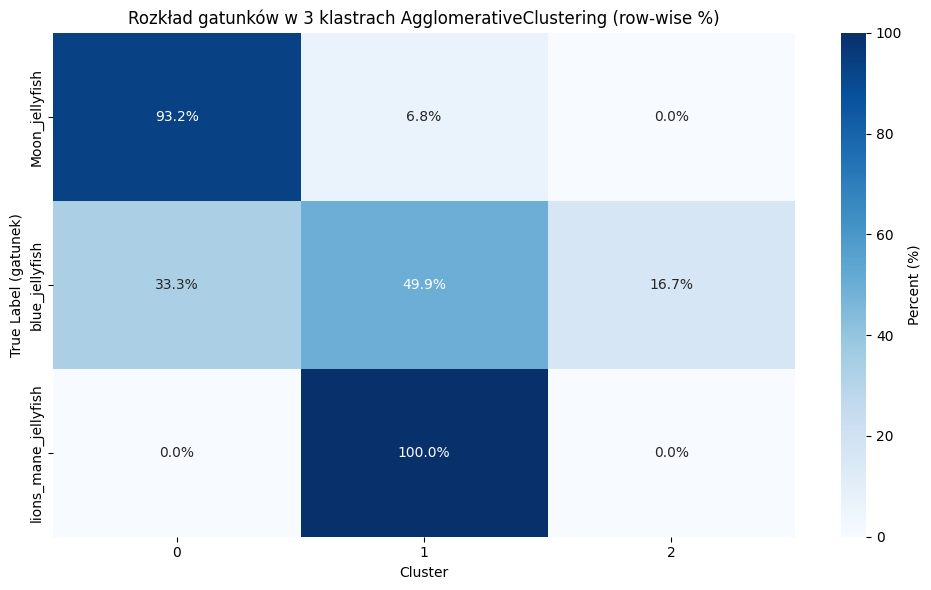

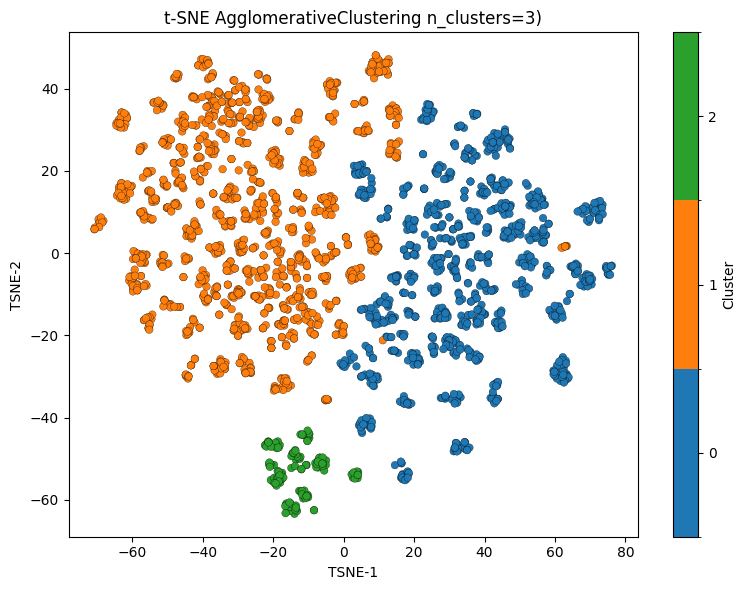

In [30]:
metrics(filtered_df["label"],y_pred)
confusion_matrix(y_pred,"AgglomerativeClustering",filtered_df)
plot_tsne_clusters(y_pred, "AgglomerativeClustering", 3)

In [31]:
unique, counts = np.unique(y_pred, return_counts=True)
dict(zip(unique, counts))

{0: 1030, 1: 1289, 2: 137}

In [32]:
filtered_df['label'].value_counts()

label
lions_mane_jellyfish    825
blue_jellyfish          819
Moon_jellyfish          812
Name: count, dtype: int64